# Quy trinh phan loai van ban (CSV)

Sua cell cau hinh ben duoi de dat:
- DATA_PATH (duong dan CSV dau vao)
- TEXT_COL, LABEL_COL
- TEST_SIZE, RANDOM_STATE
- EXPORT_PATH, REPORT_PATH

Moi buoc se in thong tin kiem tra va ve do thi de ban xem lai anh huong cua tung buoc lam sach.

In [ ]:
# Cau hinh
DATA_PATH = "data.csv"  # duong dan CSV dau vao
TEXT_COL = "text"  # cot noi dung
LABEL_COL = "label"  # cot nhan
TEST_SIZE = 0.2  # chinh theo kich thuoc tap du lieu
RANDOM_STATE = 42

# Tuy chon: bang tu long/viet tat va stopwords
SLANG_MAP = {
    "ko": "khong",
    "k": "khong",
    "dc": "duoc",
}
STOPWORDS_TOP_N = 200  # lay top N tu xuat hien nhieu nhat lam stopwords
CUSTOM_STOPWORDS = [
    # them/bot dua tren TF-IDF
]

# Import
from __future__ import annotations

import math
import unicodedata
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import regex as re2
from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

sns.set_theme(style="whitegrid")

Shape: (4995, 2)
Null counts:
 text     0
label    0
dtype: int64
Duplicate rows: 0


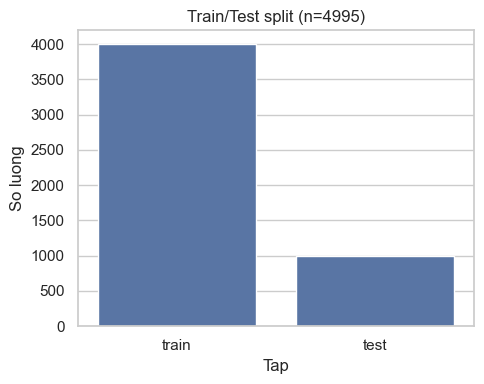

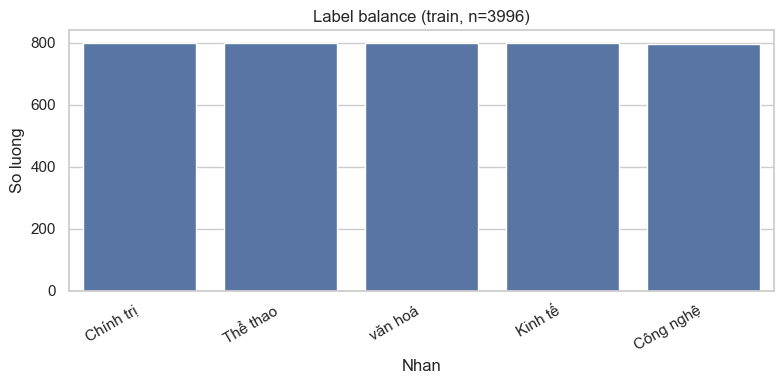

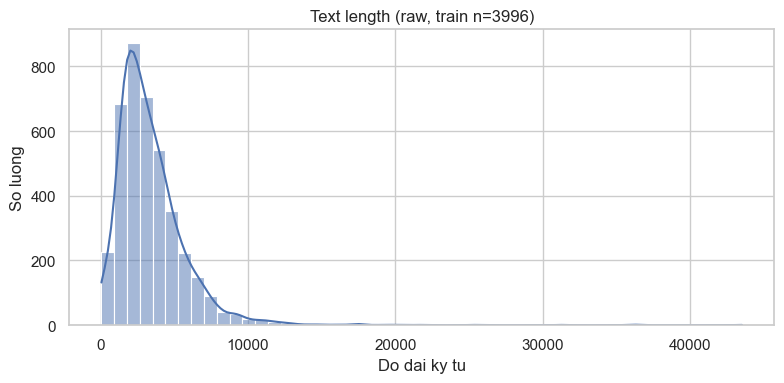

Text length summary (raw):
count     3996.000000
mean      3397.661161
std       2461.593216
min         47.000000
25%       1867.000000
50%       2890.000000
75%       4325.750000
max      43526.000000
Name: text_len_raw, dtype: float64


In [13]:
# 1) Nap du lieu va kiem tra co ban

# Nap
raw_df = pd.read_csv(DATA_PATH)

# Kiem tra cot bat buoc
missing_cols = [c for c in [TEXT_COL, LABEL_COL] if c not in raw_df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}. Available: {list(raw_df.columns)}")

# Thong tin co ban
print("Shape:", raw_df.shape)
print("Null counts:\n", raw_df[[TEXT_COL, LABEL_COL]].isna().sum())
print("Duplicate rows:", raw_df.duplicated().sum())

# Loai null va trung lap
df = raw_df.dropna(subset=[TEXT_COL, LABEL_COL]).drop_duplicates().copy()

# Dam bao kieu chuoi
df[TEXT_COL] = df[TEXT_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

# 2) Chia train/test
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df[LABEL_COL],
)

train_df = train_df.copy()
test_df = test_df.copy()
train_df["split"] = "train"
test_df["split"] = "test"

split_counts = pd.concat([train_df, test_df])["split"].value_counts().reset_index()
split_counts.columns = ["split", "count"]
plt.figure(figsize=(5, 4))
sns.barplot(data=split_counts, x="split", y="count")
plt.title(f"Train/Test split (n={len(df)})")
plt.xlabel("Tap")
plt.ylabel("So luong")
plt.tight_layout()
plt.show()

# Can bang nhan
label_counts = train_df[LABEL_COL].value_counts().reset_index()
label_counts.columns = ["label", "count"]

plt.figure(figsize=(8, 4))
sns.barplot(data=label_counts, x="label", y="count")
plt.title(f"Label balance (train, n={len(train_df)})")
plt.xlabel("Nhan")
plt.ylabel("So luong")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Phan bo do dai van ban (raw)
train_df["text_len_raw"] = train_df[TEXT_COL].str.len()
plt.figure(figsize=(8, 4))
sns.histplot(train_df["text_len_raw"], bins=50, kde=True)
plt.title(f"Text length (raw, train n={len(train_df)})")
plt.xlabel("Do dai ky tu")
plt.ylabel("So luong")
plt.tight_layout()
plt.show()

print("Text length summary (raw):")
print(train_df["text_len_raw"].describe())

In [ ]:
# 3) Lam sach muc 1 + chuan hoa tieng Viet + tach tu + lam sach muc 2 (dinh nghia ham)

URL_RE = re2.compile(r"https?://\S+|www\.\S+", re2.IGNORECASE)
EMOJI_RE = re2.compile(r"\p{Emoji_Presentation}|\p{Extended_Pictographic}")
NON_ALNUM_RE = re2.compile(r"[^\p{L}\p{N}\s_]")
MULTI_SPACE_RE = re2.compile(r"\s+")
HTML_RE = re2.compile(r"<[^>]*>")

# Chuan hoa Unicode tieng Viet (to hop -> dung san)
UNI_CHARS = "àáảãạâầấẩẫậăằắẳẵặèéẻẽẹêềếểễệđìíỉĩịòóỏõọôồốổỗộơờớởỡợùúủũụưừứửữựỳýỷỹỵÀÁẢÃẠÂẦẤẨẪẬĂẰẮẲẴẶÈÉẺẼẸÊỀẾỂỄỆĐÌÍỈĨỊÒÓỎÕỌÔỒỐỔỖỘƠỜỚỞỠỢÙÚỦŨỤƯỪỨỬỮỰỲÝỶỸỴÂĂĐÔƠƯ"
UNSIGN_CHARS = "aaaaaaaaaaaaaaaaaeeeeeeeeeeediiiiiooooooooooooooooouuuuuuuuuuuyyyyyAAAAAAAAAAAAAAAAAEEEEEEEEEEEDIIIOOOOOOOOOOOOOOOOOOOUUUUUUUUUUUYYYYYAADOOU"


def remove_html(txt: str) -> str:
    return HTML_RE.sub(" ", txt)


def loaddicchar() -> dict[str, str]:
    dic = {}
    char1252 = (
        "à|á|ả|ã|ạ|ầ|ấ|ẩ|ẫ|ậ|ằ|ắ|ẳ|ẵ|ặ|"
        "è|é|ẻ|ẽ|ẹ|ề|ế|ể|ễ|ệ|"
        "ì|í|ỉ|ĩ|ị|"
        "ò|ó|ỏ|õ|ọ|ồ|ố|ổ|ỗ|ộ|ờ|ớ|ở|ỡ|ợ|"
        "ù|ú|ủ|ũ|ụ|ừ|ứ|ử|ữ|ự|"
        "ỳ|ý|ỷ|ỹ|ỵ|"
        "À|Á|Ả|Ã|Ạ|Ầ|Ấ|Ẩ|Ẫ|Ậ|Ằ|Ắ|Ẳ|Ẵ|Ặ|"
        "È|É|Ẻ|Ẽ|Ẹ|Ề|Ế|Ể|Ễ|Ệ|"
        "Ì|Í|Ỉ|Ĩ|Ị|"
        "Ò|Ó|Ỏ|Õ|Ọ|Ồ|Ố|Ổ|Ỗ|Ộ|Ờ|Ớ|Ở|Ỡ|Ợ|"
        "Ù|Ú|Ủ|Ũ|Ụ|Ừ|Ứ|Ử|Ữ|Ự|"
        "Ỳ|Ý|Ỷ|Ỹ|Ỵ"
    ).split("|")
    charutf8 = (
        "à|á|ả|ã|ạ|ầ|ấ|ẩ|ẫ|ậ|ằ|ắ|ẳ|ẵ|ặ|"
        "è|é|ẻ|ẽ|ẹ|ề|ế|ể|ễ|ệ|"
        "ì|í|ỉ|ĩ|ị|"
        "ò|ó|ỏ|õ|ọ|ồ|ố|ổ|ỗ|ộ|ờ|ớ|ở|ỡ|ợ|"
        "ù|ú|ủ|ũ|ụ|ừ|ứ|ử|ữ|ự|"
        "ỳ|ý|ỷ|ỹ|ỵ|"
        "À|Á|Ả|Ã|Ạ|Ầ|Ấ|Ẩ|Ẫ|Ậ|Ằ|Ắ|Ẳ|Ẵ|Ặ|"
        "È|É|Ẻ|Ẽ|Ẹ|Ề|Ế|Ể|Ễ|Ệ|"
        "Ì|Í|Ỉ|Ĩ|Ị|"
        "Ò|Ó|Ỏ|Õ|Ọ|Ồ|Ố|Ổ|Ỗ|Ộ|Ờ|Ớ|Ở|Ỡ|Ợ|"
        "Ù|Ú|Ủ|Ũ|Ụ|Ừ|Ứ|Ử|Ữ|Ự|"
        "Ỳ|Ý|Ỷ|Ỹ|Ỵ"
    ).split("|")
    for i in range(len(char1252)):
        dic[char1252[i]] = charutf8[i]
    return dic


dicchar = loaddicchar()


def covert_unicode(txt: str) -> str:
    return re2.sub(
        r"à|á|ả|ã|ạ|ầ|ấ|ẩ|ẫ|ậ|ằ|ắ|ẳ|ẵ|ặ|"
        r"è|é|ẻ|ẽ|ẹ|ề|ế|ể|ễ|ệ|"
        r"ì|í|ỉ|ĩ|ị|"
        r"ò|ó|ỏ|õ|ọ|ồ|ố|ổ|ỗ|ộ|ờ|ớ|ở|ỡ|ợ|"
        r"ù|ú|ủ|ũ|ụ|ừ|ứ|ử|ữ|ự|"
        r"ỳ|ý|ỷ|ỹ|ỵ|"
        r"À|Á|Ả|Ã|Ạ|Ầ|Ấ|Ẩ|Ẫ|Ậ|Ằ|Ắ|Ẳ|Ẵ|Ặ|"
        r"È|É|Ẻ|Ẽ|Ẹ|Ề|Ế|Ể|Ễ|Ệ|"
        r"Ì|Í|Ỉ|Ĩ|Ị|"
        r"Ò|Ó|Ỏ|Õ|Ọ|Ồ|Ố|Ổ|Ỗ|Ộ|Ờ|Ớ|Ở|Ỡ|Ợ|"
        r"Ù|Ú|Ủ|Ũ|Ụ|Ừ|Ứ|Ử|Ữ|Ự|"
        r"Ỳ|Ý|Ỷ|Ỹ|Ỵ",
        lambda x: dicchar[x.group()],
        txt,
    )


# Chuan hoa kieu go dau (ve kieu cu)
BANG_NGUYEN_AM = [
    ["a", "a`,", "a'", "a~", "a.", "a?"]
]

# Bang nguyen am va mapping theo quy tac cu
BANG_NGUYEN_AM = [
    ["a", "à", "á", "ả", "ã", "ạ"],
    ["ă", "ằ", "ắ", "ẳ", "ẵ", "ặ"],
    ["â", "ầ", "ấ", "ẩ", "ẫ", "ậ"],
    ["e", "è", "é", "ẻ", "ẽ", "ẹ"],
    ["ê", "ề", "ế", "ể", "ễ", "ệ"],
    ["i", "ì", "í", "ỉ", "ĩ", "ị"],
    ["o", "ò", "ó", "ỏ", "õ", "ọ"],
    ["ô", "ồ", "ố", "ổ", "ỗ", "ộ"],
    ["ơ", "ờ", "ớ", "ở", "ỡ", "ợ"],
    ["u", "ù", "ú", "ủ", "ũ", "ụ"],
    ["ư", "ừ", "ứ", "ử", "ữ", "ự"],
    ["y", "ỳ", "ý", "ỷ", "ỹ", "ỵ"],
]

NGUYEN_AM_TO_IDS = {}
for i, bang in enumerate(BANG_NGUYEN_AM):
    for j, ch in enumerate(bang):
        NGUYEN_AM_TO_IDS[ch] = (i, j)


def is_valid_vietnam_word(word: str) -> bool:
    chars = list(word)
    nguyen_am_index = -1
    for index, char in enumerate(chars):
        x, _ = NGUYEN_AM_TO_IDS.get(char, (-1, -1))
        if x != -1:
            if nguyen_am_index == -1:
                nguyen_am_index = index
            else:
                if index - nguyen_am_index != 1:
                    return False
                nguyen_am_index = index
    return True


def chuan_hoa_dau_tu_tieng_viet(word: str) -> str:
    if not is_valid_vietnam_word(word):
        return word

    chars = list(word)
    dau_cau = 0
    nguyen_am_index = []
    qu_or_gi = False
    for index, char in enumerate(chars):
        x, y = NGUYEN_AM_TO_IDS.get(char, (-1, -1))
        if x == -1:
            continue
        elif x == 9:
            if index != 0 and chars[index - 1] == "q":
                chars[index] = "u"
                qu_or_gi = True
        elif x == 5:
            if index != 0 and chars[index - 1] == "g":
                chars[index] = "i"
                qu_or_gi = True
        if y != 0:
            dau_cau = y
            chars[index] = BANG_NGUYEN_AM[x][0]
        if not qu_or_gi or index != 1:
            nguyen_am_index.append(index)
    if len(nguyen_am_index) < 2:
        if qu_or_gi:
            if len(chars) == 2:
                x, y = NGUYEN_AM_TO_IDS.get(chars[1])
                chars[1] = BANG_NGUYEN_AM[x][dau_cau]
            else:
                x, y = NGUYEN_AM_TO_IDS.get(chars[2], (-1, -1))
                if x != -1:
                    chars[2] = BANG_NGUYEN_AM[x][dau_cau]
                else:
                    chars[1] = BANG_NGUYEN_AM[5][dau_cau] if chars[1] == "i" else BANG_NGUYEN_AM[9][dau_cau]
            return "".join(chars)
        return word

    for index in nguyen_am_index:
        x, y = NGUYEN_AM_TO_IDS[chars[index]]
        if x == 4 or x == 8:
            chars[index] = BANG_NGUYEN_AM[x][dau_cau]
            return "".join(chars)

    if len(nguyen_am_index) == 2:
        if nguyen_am_index[-1] == len(chars) - 1:
            x, y = NGUYEN_AM_TO_IDS[chars[nguyen_am_index[0]]]
            chars[nguyen_am_index[0]] = BANG_NGUYEN_AM[x][dau_cau]
        else:
            x, y = NGUYEN_AM_TO_IDS[chars[nguyen_am_index[1]]]
            chars[nguyen_am_index[1]] = BANG_NGUYEN_AM[x][dau_cau]
    else:
        x, y = NGUYEN_AM_TO_IDS[chars[nguyen_am_index[1]]]
        chars[nguyen_am_index[1]] = BANG_NGUYEN_AM[x][dau_cau]
    return "".join(chars)


def chuan_hoa_dau_cau_tieng_viet(sentence: str) -> str:
    sentence = sentence.lower()
    words = sentence.split()
    for index, word in enumerate(words):
        cw = re2.sub(r"(^\p{P}*)([\p{L}.]*\p{L}+)(\p{P}*$)", r"\1/\2/\3", word).split("/")
        if len(cw) == 3:
            cw[1] = chuan_hoa_dau_tu_tieng_viet(cw[1])
        words[index] = "".join(cw)
    return " ".join(words)


def strip_html(text: str) -> str:
    # Dung parser khi co the; fallback regex neu can
    try:
        return BeautifulSoup(text, "html.parser").get_text(" ")
    except Exception:
        return remove_html(text)


def normalize_text(text: str) -> str:
    text = unicodedata.normalize("NFKC", text)
    text = strip_html(text)
    text = URL_RE.sub(" ", text)
    text = EMOJI_RE.sub(" ", text)
    text = covert_unicode(text)
    text = chuan_hoa_dau_cau_tieng_viet(text)
    text = text.lower()
    text = MULTI_SPACE_RE.sub(" ", text).strip()
    return text


def collapse_repeat_tokens(text: str) -> str:
    tokens = text.split()
    if not tokens:
        return text
    deduped = [tokens[0]]
    for tok in tokens[1:]:
        if tok != deduped[-1]:
            deduped.append(tok)
    return " ".join(deduped)


def apply_slang_map(text: str, slang_map: dict[str, str]) -> str:
    if not slang_map:
        return text
    for k, v in slang_map.items():
        text = re2.sub(rf"\b{re2.escape(k)}\b", v, text)
    return text


def clean_level2(text: str) -> str:
    text = apply_slang_map(text, SLANG_MAP)
    text = NON_ALNUM_RE.sub(" ", text)
    text = MULTI_SPACE_RE.sub(" ", text).strip()
    text = collapse_repeat_tokens(text)
    return text


def apply_cleaning(dfx: pd.DataFrame) -> pd.DataFrame:
    dfx = dfx.copy()
    dfx["text_clean_l1"] = dfx[TEXT_COL].map(normalize_text)
    dfx["text_clean"] = dfx["text_clean_l1"].map(clean_level2)
    return dfx


def build_stopwords_and_vectorizer(train_text: pd.Series) -> tuple[set[str], TfidfVectorizer]:
    vectorizer = TfidfVectorizer(
        max_features=5000,
        token_pattern=r"(?u)\b\w+\b",
    )
    vectorizer.fit(train_text)

    # Lay top N tu xuat hien nhieu nhat lam stopwords
    tokens = train_text.str.split().explode().dropna()
    term_counts = Counter(tokens)
    auto_stop = {term for term, _ in term_counts.most_common(STOPWORDS_TOP_N)}

    stopwords = set(CUSTOM_STOPWORDS) | auto_stop
    return stopwords, vectorizer


def apply_stopwords(text_series: pd.Series, stopwords: set[str]) -> pd.Series:
    if not stopwords:
        return text_series
    stop_re = re2.compile(r"\b(" + "|".join(map(re2.escape, sorted(stopwords))) + r")\b")
    return text_series.map(lambda x: MULTI_SPACE_RE.sub(" ", stop_re.sub(" ", x)).strip())


def plot_top_terms_by_label(train_text: pd.Series, train_labels: pd.Series, vectorizer: TfidfVectorizer) -> None:
    X_train = vectorizer.transform(train_text)
    terms = np.array(vectorizer.get_feature_names_out())

    labels = sorted(train_labels.unique())
    for label in labels:
        idx = train_labels[train_labels == label].index
        if len(idx) == 0:
            continue
        rows = train_labels.index.get_indexer(idx)
        mean_tfidf = X_train[rows].mean(axis=0).A1
        top_idx = np.argsort(mean_tfidf)[-10:][::-1]
        top_terms = terms[top_idx]
        top_scores = mean_tfidf[top_idx]

        plt.figure(figsize=(8, 4))
        sns.barplot(x=top_scores, y=top_terms, orient="h")
        plt.title(f"Top TF-IDF terms: {label}")
        plt.xlabel("TF-IDF trung binh")
        plt.ylabel("Tu")
        plt.tight_layout()
        plt.show()


def build_pipeline(steps: list[dict]) -> dict:
    def fit(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
        state = {}
        cur = df.copy()
        for step in steps:
            cur, state = step["fit"](cur, state)
        return cur, state

    def transform(df: pd.DataFrame, state: dict) -> pd.DataFrame:
        cur = df.copy()
        for step in steps:
            cur = step["transform"](cur, state)
        return cur

    return {"fit": fit, "transform": transform}


def step_clean_fit(df: pd.DataFrame, state: dict) -> tuple[pd.DataFrame, dict]:
    cleaned = apply_cleaning(df)
    return cleaned, state


def step_clean_transform(df: pd.DataFrame, state: dict) -> pd.DataFrame:
    return apply_cleaning(df)


def step_stopwords_fit(df: pd.DataFrame, state: dict) -> tuple[pd.DataFrame, dict]:
    stopwords, vectorizer = build_stopwords_and_vectorizer(df["text_clean"])
    new_state = dict(state)
    new_state["stopwords"] = stopwords
    new_state["vectorizer"] = vectorizer
    new_state["len_clean"] = df["text_clean"].str.len().to_numpy()
    return df, new_state


def step_stopwords_transform(df: pd.DataFrame, state: dict) -> pd.DataFrame:
    if "stopwords" not in state:
        raise ValueError("Missing stopwords in pipeline state")
    df = df.copy()
    df["text_clean"] = apply_stopwords(df["text_clean"], state["stopwords"])
    return df


# (bo phan kiem tra tokenize vi khong con tach tu)

d:\PROJECT\bài tập trên lớp\KHDL\.venv\Lib\site-packages\pyvi\ViTokenizer.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  model = pickle.load(fin)


In [15]:
# if "text_tok" not in train_df.columns:
#     train_df = apply_cleaning(train_df)

# print(check_tokenization(train_df["text_tok"], sample_size=10))

In [16]:
# 4a) Buoc clean: fit tren train, transform tren test

train_df, state = step_clean_fit(train_df, {})
test_df = step_clean_transform(test_df, state)

print("Clean done. Columns:", [c for c in ["text_clean_l1", "text_tok", "text_clean"] if c in train_df.columns])

Clean done. Columns: ['text_clean_l1', 'text_tok', 'text_clean']


In [17]:
# liệt kê mỗi nhãn top 10 từ xuất nhiều nhất trong mỗi nhãn (từ:số lần xuất hiện trong tất cả bản ghi có cùng nhãn) lưu dưới dạng danh sách
def get_top_terms_by_label(text_series: pd.Series, label_series: pd.Series, top_n: int = 10) -> dict[str, list[tuple[str, int]]]:
    label_to_terms = {}
    for label in sorted(label_series.unique()):
        idx = label_series[label_series == label].index
        if len(idx) == 0:
            continue
        terms = text_series.loc[idx].str.split(expand=True).stack()
        term_counts = Counter(terms)
        top_terms = term_counts.most_common(top_n)
        label_to_terms[label] = top_terms
    return label_to_terms
pre_top_n = 10
top_terms_pre = get_top_terms_by_label(train_df["text_clean"], train_df[LABEL_COL], top_n=pre_top_n)

In [18]:
# 4b) Buoc stopwords: fit tren train, transform tren test

pre_stop_text = train_df["text_clean"].copy()

train_df, state = step_stopwords_fit(train_df, state)
train_df = step_stopwords_transform(train_df, state)
test_df = step_stopwords_transform(test_df, state)

In [19]:
## liệt kê top theo PRE để so sánh công bằng với POST

top_terms_post_stop = get_top_terms_by_label(train_df["text_clean"], train_df[LABEL_COL], top_n=pre_top_n)

for label in sorted(train_df[LABEL_COL].unique()):
    print(f"Label: {label}")
    pre = dict(top_terms_pre.get(label, []))
    post = dict(top_terms_post_stop.get(label, []))

    terms = list(pre.keys())
    print(f"{'Term':<20} {'Pre-Stop':>10} {'Post-Stop':>10}")
    for term in terms:
        pre_count = pre.get(term, 0)
        post_count = post.get(term, 0)
        print(f"{term:<20} {pre_count:>10} {post_count:>10}")
    print("-" * 40)

Label: Chính trị
Term                   Pre-Stop  Post-Stop
nan                     3380073    1728222
và                        12775          0
các                       10415          0
của                        9460          0
trong                      5565          0
tỉnh                       4597          0
tổ_chức                    4422          0
với                        4348          0
là                         4229          0
có                         4199          0
----------------------------------------
Label: Công nghệ
Term                   Pre-Stop  Post-Stop
nan                     1023817     486110
và                         7677          0
của                        6561          0
các                        5786          0
trong                      5172          0
cho                        4622          0
với                        4449          0
là                         3997          0
được                       3986          0
có                    

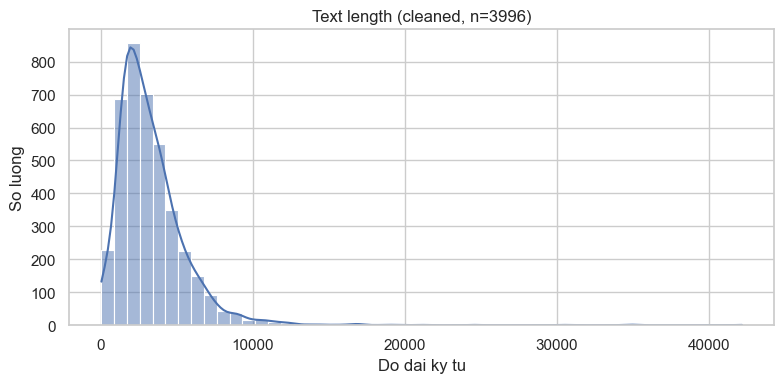

Text length summary (cleaned):
Mean: 3300.61
Median: 2807.50
Min: 45.00
Max: 42168.00
Auto stopwords count: 250
Total stopwords count: 250
Danh sach stopwords:
['000', '1', '10', '12', '2', '2024', '2025', '21', '3', '4', '5', '551', '6', '7', '8', '9', 'ai', 'anh', 'ban', 'biên', 'biết', 'bên', 'bóp_méo', 'bước', 'bằng', 'bị', 'bộ', 'bộ_máy', 'cao', 'cao_tốc', 'chia_sẻ', 'cho', 'chính', 'chính_phủ', 'chưa', 'chương_trình', 'chỉ', 'chủ_trương', 'chủ_tịch', 'cuối', 'cuộc', 'các', 'cách', 'còn', 'có', 'có_thể', 'công_bố', 'công_nghệ', 'công_ty', 'công_tác', 'cùng', 'cũng', 'cơ_hội', 'cơ_quan', 'cơ_sở', 'cạnh', 'cả', 'cấp', 'cần', 'cẩn_trọng', 'của', 'diễn', 'do', 'doanh_nghiệp', 'dân', 'dù', 'dự_kiến', 'dự_án', 'giá_trị', 'giúp', 'giảm', 'giữ', 'giữa', 'góp_phần', 'gần', 'gồm', 'hai', 'hay', 'hiện', 'hiệu_quả', 'hoạt_động', 'hoặc', 'hàng', 'hòa', 'hơn', 'hướng', 'hệ_thống', 'họ', 'hỗ_trợ', 'khi', 'khoảng', 'khu_vực', 'khác', 'không', 'khả_năng', 'kinh_tế', 'kế_hoạch', 'kết_quả', 'liên_qu

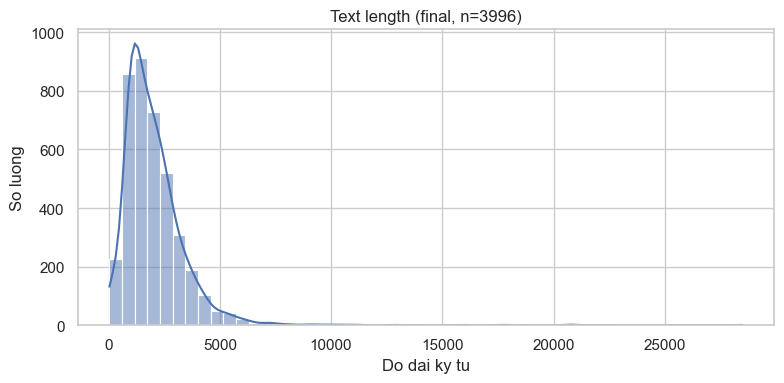

Text length summary (final):
count     3996.000000
mean      2016.635135
std       1421.620528
min         36.000000
25%       1127.750000
50%       1744.000000
75%       2560.500000
max      28488.000000
Name: text_len_final, dtype: float64


In [26]:

# Bieu do do dai sau lam sach (truoc stopwords)
len_clean = state.get("len_clean")
if len_clean is not None:
    plt.figure(figsize=(8, 4))
    sns.histplot(len_clean, bins=50, kde=True)
    plt.title(f"Text length (cleaned, n={len(len_clean)})")
    plt.xlabel("Do dai ky tu")
    plt.ylabel("So luong")
    plt.tight_layout()
    plt.show()

    AVG_LEN_CLEAN = float(np.mean(len_clean))
else:
    AVG_LEN_CLEAN = float("nan")
#Tong quan do dai sau lam sach (truoc stopwords)
print("Text length summary (cleaned):")
if len_clean is not None:
    print(f"Mean: {AVG_LEN_CLEAN:.2f}")
    print(f"Median: {float(np.median(len_clean)):.2f}")
    print(f"Min: {float(np.min(len_clean)):.2f}")
    print(f"Max: {float(np.max(len_clean)):.2f}")
    
# Stopwords va vectorizer
stopwords = state.get("stopwords", set())
vectorizer = state.get("vectorizer")
stopwords_list = sorted(stopwords)

print("Auto stopwords count:", len(set(stopwords) - set(CUSTOM_STOPWORDS)))
print("Total stopwords count:", len(stopwords))
print("Danh sach stopwords:")
print(stopwords_list)

#bảng Minh hoa stopword  có trọng số nhỏ nhất
if vectorizer is not None:
    idf = vectorizer.idf_
    terms = np.array(vectorizer.get_feature_names_out())
    term_idf = dict(zip(terms, idf))
    sorted_terms = sorted(term_idf.items(), key=lambda x: x[1])
    print("Top 20 terms with lowest IDF (most common):")
    for term, score in sorted_terms[:20]:
        print(f"{term}: {score:.4f}")
# Ve do dai sau stopwords
combined =train_df
combined["text_len_final"] = combined["text_clean"].str.len()
plt.figure(figsize=(8, 4))
sns.histplot(combined["text_len_final"], bins=50, kde=True)
plt.title(f"Text length (final, n={len(combined)})")
plt.xlabel("Do dai ky tu")
plt.ylabel("So luong")
plt.tight_layout()
plt.show()
# Tong quan do dai sau stopwords
print("Text length summary (final):")
print(combined["text_len_final"].describe())

# 5) Xuat du lieu ra 2  file train.csv va test.csv sau khi da lam sach
final_cols = [LABEL_COL, "text_clean"]
train_df[final_cols].to_csv("train.csv", index=False)
test_df[final_cols].to_csv("test.csv", index=False)
# Neu muon xem tu khoa noi bat theo nhan, goi ham nay:
# plot_top_terms_by_label(train_df["text_clean"], train_df[LABEL_COL], vectorizer)

In [23]:
#kiểm tra tỉ lệ mỗi nhãn trên tập train và test
train_label_dist = train_df[LABEL_COL].value_counts(normalize=True)
test_label_dist = test_df[LABEL_COL].value_counts(normalize=True)
label_dist_df = pd.DataFrame({
    "label": train_label_dist.index,
    "train_ratio": train_label_dist.values,
    "test_ratio": test_label_dist.reindex(train_label_dist.index, fill_value=0).values
})
print("Label distribution in train and test:")
print(label_dist_df)


Label distribution in train and test:
       label  train_ratio  test_ratio
0  Chính trị     0.200200    0.200200
1   Thể thao     0.200200    0.200200
2    văn hoá     0.200200    0.200200
3    Kinh tế     0.200200    0.200200
4  Công nghệ     0.199199    0.199199
